In [98]:
import requests
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime, timedelta, timezone

In [104]:
import requests

url = "https://api.elections.kalshi.com/trade-api/v2/series?include_volume=true"

response = requests.get(url).json()
data = pd.DataFrame(response["series"])

In [105]:
series_results = []
series_tickers = list(data.ticker.unique())[:1000]
for ticker in tqdm(series_tickers):
    # Gamma API endpoint for series details
    url = f"https://api.elections.kalshi.com/trade-api/v2/markets/"
    params = {"series_ticker":ticker, "limit" : 1000}
    
    response = requests.get(url, params=params)
    data = response.json()
    series_results.append(data)


100%|██████████| 1000/1000 [08:32<00:00,  1.95it/s]


In [ ]:
all_ticker_data = []
for x in series_results:
    markets = x["markets"]
    for market in markets:
        all_ticker_data.append(market)
all_ticker_data = pd.DataFrame(all_ticker_data)

In [109]:
tickers_timing_data = all_ticker_data[["close_time", "created_time", "ticker"]].set_index("ticker")

In [110]:
tickers_list = list(tickers_timing_data.index.unique())

In [113]:
pd.Series(tickers_list).to_csv('tickers.csv', index=False)

In [183]:
# Configuration temporelle
end_ts = int((datetime.now() - timedelta(days=1)).timestamp())
start_ts = int((datetime.now() - timedelta(days=1000)).timestamp())
interval = 1440 

url = "https://api.elections.kalshi.com/trade-api/v2/markets/candlesticks"

all_candles = {}
batch_size = 10

# Boucle par lots de 100 tickers
for i in tqdm(range(0, len(tickers_list), batch_size)):
    batch = tickers_list[i : i + batch_size]
    
    params = {
        "market_tickers": ",".join(batch),
        "start_ts": start_ts,
        "end_ts": end_ts,
        "period_interval": interval,
        "include_latest_before_start": "false"
    }

    res = requests.get(url, params=params)
    data = res.json()

    for m in data.get("markets", []):
        ticker = m.get("market_ticker")
        candles = m.get("candlesticks", [])
        all_candles[ticker] = candles



100%|██████████| 3128/3128 [16:17<00:00,  3.20it/s]


In [184]:
rows = []
for ticker, candles in all_candles.items():
    for c in candles:
        # Merge top level with 'price' nested dict
        row = {
            "ticker": ticker,
            "ts": pd.to_datetime(c["end_period_ts"], unit="s", utc=True),
            "volume": c.get("volume"),
            **c.get("price", {})
        }
        rows.append(row)

df = pd.DataFrame(rows).set_index(["ts","ticker"]).sort_index().astype("float")

In [185]:
processed_df = pd.DataFrame()
processed_df['volatility_id'] = (df['high'] - df['low']) / df['open']
processed_df['return'] = df.groupby(level=0)['close'].pct_change()
processed_df['price_loc'] = (df['close'] - df['low']) / (df['high'] - df['low'] + 1e-9)
processed_df['body_ratio'] = np.abs(df['close'] - df['open']) / (df['high'] - df['low'] + 1e-9)
processed_df['dollar_volume'] = df['volume'] * df['mean_dollars']
processed_df['mean_dev'] = (df['close_dollars'] - df['mean_dollars']) / df['mean_dollars']

/var/folders/b3/wb1ksqsd6tv5s9jff9pnm7hw0000gn/T/ipykernel_4688/421528858.py:3: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  processed_df['return'] = df.groupby(level=0)['close'].pct_change()


In [186]:
lagged_frames = [
    processed_df.groupby(level=1).shift(i).add_suffix(f'_Lagged_{i}') 
    for i in range(4)
]

# Concatenate horizontally to get the final feature set
df_lagged = pd.concat(lagged_frames, axis=1)

In [187]:
y = df_lagged["return_Lagged_0"].dropna()
X = df_lagged.loc[:, ~df_lagged.columns.str.contains("0")].loc[y.index]

In [188]:
import lightgbm as lgb
from sklearn.metrics import r2_score, accuracy_score

X = X.sort_index(level=0)
y = y.loc[X.index]

days = X.index.get_level_values(0).unique().sort_values()
min_train_days = 10
results = []
iter_metrics = []

for i in tqdm(range(min_train_days, len(days))):
    train_days = days[:i]
    test_day = days[i]
    
    X_train, y_train = X.loc[train_days], y.loc[train_days]
    X_test, y_test = X.loc[[test_day]], y.loc[[test_day]]
    
    if len(X_train) < 50 or len(X_test) == 0: 
        continue
        
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, verbosity=-1)
    model.fit(X_train, y_train)
    
    y_hat_train = model.predict(X_train)
    y_hat_test = model.predict(X_test)

    r2_train = r2_score(y_train, y_hat_train)
    r2_test = r2_score(y_test, y_hat_test)
    
    acc_train = accuracy_score(np.sign(y_train.values), np.sign(y_hat_train))
    acc_test = accuracy_score(np.sign(y_test.values), np.sign(y_hat_test))

    raw_pnl = y_hat_test * y_test.values
    daily_exposure = np.sum(np.abs(y_hat_test)) + 1e-9
    norm_weight = y_hat_test / daily_exposure
    norm_pnl = norm_weight * y_test.values
    
    iter_metrics.append({
        'ts': test_day,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'daily_raw_pnl': np.sum(raw_pnl),
        'daily_norm_pnl': np.sum(norm_pnl)
    })
    
    results.append(pd.DataFrame({
        'ticker': X_test.index.get_level_values(1), # Le ticker est au niveau 1
        'y_true': y_test.values,
        'y_hat': y_hat_test,
        'raw_pnl': raw_pnl,
        'norm_pnl': norm_pnl
    }, index=X_test.index))

# Synthèse finale
final_df = pd.concat(results).drop(columns = "ticker")
metrics_df = pd.DataFrame(iter_metrics).set_index('ts')

print("\n--- Mean Metrics ---")
print(metrics_df[['r2_test', 'acc_test', 'daily_norm_pnl']].mean())

100%|██████████| 989/989 [08:32<00:00,  1.93it/s]



--- Mean Metrics ---
r2_test          -1.974384
acc_test          0.202265
daily_norm_pnl    8.576661
dtype: float64


In [192]:
raw_pnl_mat = final_df.reset_index().pivot(index = "ts", columns = "ticker", values = "raw_pnl").sum(1)
norm_pnl_mat = final_df.reset_index().pivot(index = "ts", columns = "ticker", values = "norm_pnl").sum(1)

9.340075511397442

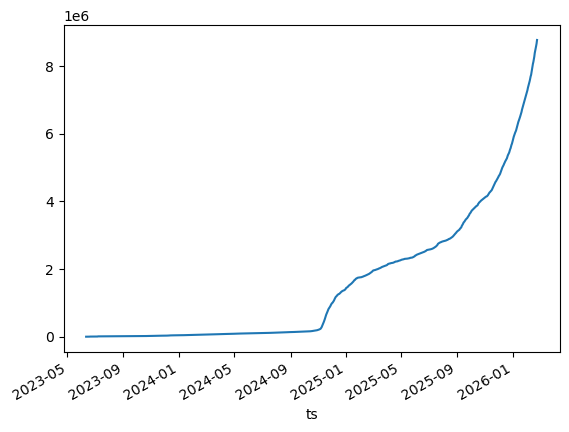

In [193]:
raw_pnl_mat.cumsum().plot()
16*raw_pnl_mat.mean()/raw_pnl_mat.std()

15.545993219991878

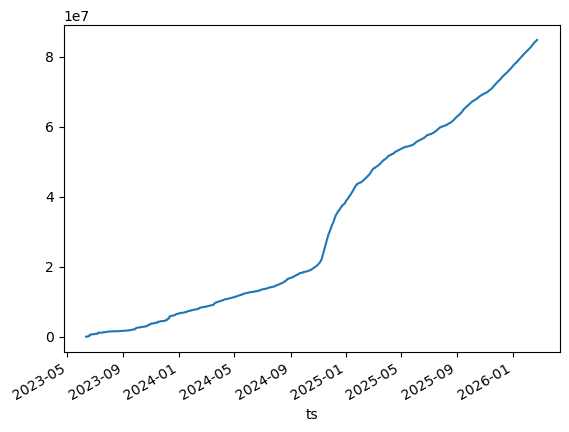

In [195]:
VaR = 1e4
(VaR*norm_pnl_mat).cumsum().plot()
16*norm_pnl_mat.mean()/norm_pnl_mat.std()